In [1]:
# ==========================================
# CODE 6 / NOTEBOOK 6
# NARRATIVE PATTERNS AND CASE EXAMPLES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 250)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
# -----------------------------
# 1. LOAD CLEANED DATA
# -----------------------------
df = pd.read_csv("occurrences_cleaned.csv")
df.head()

,occurrence_id,local_date_main_event,date_main_event_unconfirmed,year_reported,occurrence_severity,main_event_l1,main_event_l2,main_event_l3,not_vessel_operations,short_description,description,national_keywords,emcip_keywords,sar_intervention,state_reporting,occurrence_location,coastal_state_affected,national_location_l1,national_location_l2,latitude,longitude,lat_long_unknown,port_of_accident_l1,port_of_accident_l2,natural_light,sea_state,visibility,weather,wind_force,publication_date,publication_no,publication_type,published_report_website_link,occurrence_record_modified_on,last_updated_at,occurrences_reported_from,occurrences_reported_to
0,1f59ae23-e48f-ec11-b400-000d3a874c7b,2022-02-01,No,2022,Marine Incident,Contact,Shore Object,NaN,False,A ro-ro cargo vessel made contact with quay side,A ro-ro cargo vessel was manoeuvring to line up to enter a lock when the vessel made contact with the eastern approach causing damage to at least two fenders. A tug was assisting the vessel.,NaN,NaN,No,UK,Internal waters -> Port area,UNITED KINGDOM,United Kingdom,England,53.6383,-0.199300,NaN,UNITED KINGDOM,Immingham,Unknown,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-01-29,2026-05-15,2020-01-01,2025-12-31
1,c51366b7-39cd-ec11-a7b6-0022481a81f8,2022-04-01,No,2022,Marine Incident,Damage / Loss Of Equipment,NaN,NaN,False,A service vessel drifted from a quayside resulting in a gangway falling into the water,"A service vessel entered a port through lock gates and came alongside with a tie up of a breast line forward and aft. A gangway was then deployed. The vessel started to drift astern with the bow canting slightly, resulting in the gangway twisting...",NaN,NaN,No,UK,Internal waters -> Port area,UNITED KINGDOM,United Kingdom,Scotland,55.9869,-3.176900,NaN,UNITED KINGDOM,Leith,Daylight,1 - Calm rippled - (0 - 0.1 m),Good - 5.0 <= Vis < 25.0 nm,Clear,4 - Moderate Breeze - knot (11-16) m/s (6-8),NaN,NaN,NaN,NaN,2025-03-28,2026-05-15,2020-01-01,2025-12-31
2,883d7a39-90e1-ec11-bb3d-000d3a0cda10,2022-05-01,No,2022,Marine Incident,Accident to person(s),NaN,NaN,False,A inland passenger vessel passenger fell down stairs resulting in a head laceration,An inland waterways passenger vessel passenger fell whilst onboard resulting in a head injury. The passenger refused assistance from an ambulance and made their own way to hospital.,NaN,NaN,No,UK,Inland waters -> River,UNITED KINGDOM,United Kingdom,England,51.5074,-0.082500,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-03-13,2026-05-15,2020-01-01,2025-12-31
3,68afeb11-12ee-ec11-bb3c-000d3a0d2897,2022-06-01,No,2022,Marine Incident,Loss Of Control,Loss Of Propulsion Power,NaN,False,Fishing vessel's gearbox failed resulting in a tow.,Fishing vessel's gearbox failed resulting in a tow from another fishing vessel. The casualty vessel was not in danger at any point.,NaN,NaN,No,UK,Open sea -> Within EEZ,None/Register withdrawn,NaN,NaN,50.0644,-3.417183,NaN,NaN,NaN,Daylight,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-01-29,2026-05-15,2020-01-01,2025-12-31
4,d40d9f19-bd0c-ed11-b83d-0022481b1890,2022-07-01,No,2022,Less Serious,Accident to person(s),NaN,NaN,False,A sailing yacht crew member sustained a partial amputation to two fingers,"A sailing yacht was seeking shelter as the wind was due, the crew set about stowing the sails. The furling gear had loosened, a crew member went forward to furl the genoa. As they rotated the furling gear the genoa released catching the crew memb...",NaN,NaN,Yes,UK,Coastal waters <= 12 nm,UNITED KINGDOM,United Kingdom,Scotland,56.2847,-6.243700,NaN,NaN,NaN,Daylight,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-02-23,2026-05-15,2020-01-01,2025-12-31


In [3]:
# -----------------------------
# 2. BASIC PREPARATION
# -----------------------------
df.columns = df.columns.str.strip().str.lower()

df["local_date_main_event"] = pd.to_datetime(df["local_date_main_event"], errors="coerce")
df["eventyear"] = df["local_date_main_event"].dt.year

print("Dataset shape:", df.shape)

Dataset shape: (8599, 38)


In [4]:
# -----------------------------
# 3. CLEAN TEXT FIELDS
# -----------------------------
def clean_text(series):
    s = series.astype("string").str.strip()
    s = s.replace({
        "<NA>": pd.NA,
        "NA": pd.NA,
        "N/A": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "": pd.NA
    })
    return s

df["short_description_clean"] = clean_text(df["short_description"])
df["description_clean"] = clean_text(df["description"])
df["severityplot"] = df["occurrence_severity"].astype("string").str.strip()
df["eventl1plot"] = df["main_event_l1"].astype("string").str.strip()
df["sarplot"] = df["sar_intervention"].astype("string").str.strip()

df["short_description_clean"] = df["short_description_clean"].fillna("Missing")
df["description_clean"] = df["description_clean"].fillna("Missing")
df["severityplot"] = df["severityplot"].fillna("Unknown")
df["eventl1plot"] = df["eventl1plot"].fillna("Unknown")
df["sarplot"] = df["sarplot"].replace({
    "YES": "Yes", "yes": "Yes",
    "NO": "No", "no": "No",
    "UNKNOWN": "Unknown", "unknown": "Unknown"
}).fillna("Unknown")

In [5]:
# -----------------------------
# 4. DESCRIPTION COMPLETENESS
# -----------------------------
text_completeness = pd.DataFrame({
    "field": ["short_description", "description"],
    "missing_count": [
        (df["short_description_clean"] == "Missing").sum(),
        (df["description_clean"] == "Missing").sum()
    ]
})

text_completeness["missing_pct"] = (text_completeness["missing_count"] / len(df)) * 100

print("\n===== TEXT COMPLETENESS =====")
print(text_completeness.round({"missing_pct": 2}))


===== TEXT COMPLETENESS =====
               field  missing_count  missing_pct
0  short_description              0          0.0
1        description              0          0.0


In [6]:
# -----------------------------
# 4. DESCRIPTION COMPLETENESS
# -----------------------------
text_completeness = pd.DataFrame({
    "field": ["short_description", "description"],
    "missing_count": [
        (df["short_description_clean"] == "Missing").sum(),
        (df["description_clean"] == "Missing").sum()
    ]
})

text_completeness["missing_pct"] = (text_completeness["missing_count"] / len(df)) * 100

print("\n===== TEXT COMPLETENESS =====")
print(text_completeness.round({"missing_pct": 2}))


===== TEXT COMPLETENESS =====
               field  missing_count  missing_pct
0  short_description              0          0.0
1        description              0          0.0


In [7]:
# -----------------------------
# 5. TEXT LENGTH FEATURES
# -----------------------------
df["short_desc_chars"] = df["short_description_clean"].str.len()
df["full_desc_chars"] = df["description_clean"].str.len()

length_summary = pd.DataFrame({
    "metric": ["short_desc_chars", "full_desc_chars"],
    "mean_chars": [df["short_desc_chars"].mean(), df["full_desc_chars"].mean()],
    "median_chars": [df["short_desc_chars"].median(), df["full_desc_chars"].median()],
    "max_chars": [df["short_desc_chars"].max(), df["full_desc_chars"].max()]
})

print("\n===== TEXT LENGTH SUMMARY =====")
print(length_summary.round(2))


===== TEXT LENGTH SUMMARY =====
             metric  mean_chars  median_chars  max_chars
0  short_desc_chars       69.66          67.0        373
1   full_desc_chars      295.84         253.0       2102


In [8]:
# -----------------------------
# 6. LONGEST FULL DESCRIPTIONS
# -----------------------------
longest_cases = (
    df.loc[df["description_clean"] != "Missing", [
        "occurrence_id",
        "local_date_main_event",
        "occurrence_severity",
        "main_event_l1",
        "sar_intervention",
        "short_description_clean",
        "description_clean",
        "full_desc_chars"
    ]]
    .sort_values("full_desc_chars", ascending=False)
    .head(10)
)

print("\n===== LONGEST FULL DESCRIPTIONS =====")
display(longest_cases)


===== LONGEST FULL DESCRIPTIONS =====


,occurrence_id,local_date_main_event,occurrence_severity,main_event_l1,sar_intervention,short_description_clean,description_clean,full_desc_chars
57,e4eda6d9-347d-ec11-8d21-00224800e907,2021-11-01,Marine Incident,Collision,No,Close quarters situation between two Ro-Ro passenger vessels.,"A ro-pax vessel (1) was on passage and approaching a channel, vessel 1 was navigating off the charted course line (but in safe water) as provided by the company passage plan for the route. This led to the vessel ‘cutting the corner’ and entering...",2102
8496,ff2706ae-112b-eb11-a813-000d3a86d581,2020-11-01,Serious,Grounding / Stranding,No,A general cargo vessel grounded.,"A small general cargo vessel was on passage overnight. Its primary means of navigation was paper charts and there was no electronic plotter on board. To avoid forecasted strong winds and remain in sheltered waters, the master decided to switch to...",1958
2209,253ae087-6b3c-f011-8c4e-002248c611f0,2025-05-01,Marine Incident,Damage / Loss Of Equipment,No,Cargo ship's pilot ladder did not conform to SOLAS regulations.,"Cargo ship's pilot ladder did not conform to SOLAS regulations. First boarding attempt 25/05/2025 @ 2250 Weather conditions: 33 knots SW 1.7 - 2.5m Swell breaking over the lower deck, making it inaccessible. Crew members were observed standi...",1847
5213,577b0158-5046-ee11-be6e-002248c87a58,2023-08-01,Marine Incident,Loss Of Control,No,Crew vessel had oil spill within port limits which was cleared up.,"Whilst conducting crane competency training on the forward deck utilising the hydraulic system, the starboard fuel transfer pump was activated by human error leading to the pump running unknowingly. The pump was filling the starboard day tank. As...",1718
2249,4bfc9f74-b30c-ec11-b6e6-0022481a9982,2021-08-01,Less Serious,Grounding / Stranding,No,**REDACTED**,A SAR (search and rescue) vessel was launched to assist a RHIB with four persons on board that had had engine failure and was drifting towards sea defence rocks. Just prior to arriving on scene the SAR vessel was informed that the casualty vessel...,1665
2190,4a31e6ee-32de-ef11-8ee9-6045bd0d7007,2025-01-01,Marine Incident,Loss Of Control,No,Ro-cargo vessel surged after getting caught in a wash from ro-pax ferry.,"A ro-pax ferry was alongside at a berth, along with another ro-ro cargo vessel that was being cleaned , second officer onboard the ro-ro cargo vessel advised their chief officer that the ro-pax ferry had given then fifteen minutes' notice. The ...",1545
5880,7785c3a1-adcc-ed11-a7c6-002248c87a1d,2023-03-01,Marine Incident,Damage / Loss Of Equipment,No,A LPG tanker parted an aft breast-line whilst unmooring.,An LPG tanker parted an aft breast-line when unmooring. The tug on aft stations was asked to change position to the accommodation block as the aft spring lines and aft breast-lines were tangled on the deck and required being slackened before bein...,1520
6060,e2bec9db-12a0-ee11-be37-002248c87a51,2023-12-01,Less Serious,Accident to person(s),No,"Cargo vessel crew member stood on a mooring line, rolled their ankle and suffered a fracture","The accident happened 30 seconds before the vessel was at the pier and just before the IP was ready to put side ropes on. It was around 4pm, there was limited natural light (as at 4pm it is dark), but there was some artificial light from the vess...",1520
242,b2133fe2-aab1-ec11-983f-0022481b428e,2022-03-01,Serious,Contact,No,"Ro-Ro Ferry partially lost propulsion made and contact with quayside, causing the hull to be holed","Ro-Ro Ferry partially lost propulsion and made contact with quayside, causing the hull to be holed approximately 1 meter above the waterline. The vessel was approaching its destination, intending to berth. Due to the weather conditions in the po...",1509
5503,4c470b94-4391-ef11-8a69-002248007767,2024-10-01,Less Serious,Accident to person(s),No,Barge crew members attempted to move several steel plates by hand without any appropriate equipment and t

In [9]:
# -----------------------------
# 7. EXAMPLE INCIDENTS BY SEVERITY
# -----------------------------
severity_examples = (
    df.loc[df["description_clean"] != "Missing", [
        "local_date_main_event",
        "occurrence_severity",
        "main_event_l1",
        "sar_intervention",
        "short_description_clean",
        "description_clean",
        "full_desc_chars"
    ]]
    .sort_values(["occurrence_severity", "full_desc_chars"], ascending=[True, False])
    .groupby("occurrence_severity")
    .head(3)
)

print("\n===== EXAMPLE INCIDENTS BY SEVERITY =====")
display(severity_examples)


===== EXAMPLE INCIDENTS BY SEVERITY =====


,local_date_main_event,occurrence_severity,main_event_l1,sar_intervention,short_description_clean,description_clean,full_desc_chars
2249,2021-08-01,Less Serious,Grounding / Stranding,No,**REDACTED**,A SAR (search and rescue) vessel was launched to assist a RHIB with four persons on board that had had engine failure and was drifting towards sea defence rocks. Just prior to arriving on scene the SAR vessel was informed that the casualty vessel...,1665
6060,2023-12-01,Less Serious,Accident to person(s),No,"Cargo vessel crew member stood on a mooring line, rolled their ankle and suffered a fracture","The accident happened 30 seconds before the vessel was at the pier and just before the IP was ready to put side ropes on. It was around 4pm, there was limited natural light (as at 4pm it is dark), but there was some artificial light from the vess...",1520
5503,2024-10-01,Less Serious,Accident to person(s),No,Barge crew members attempted to move several steel plates by hand without any appropriate equipment and two were injured.,"The barge was alongside at the time, when three crew members were tasked to move a number of 2m by 1m steel deck plates, each with a thickness of 6mm and these plates had been stored upright, secured by a ratchet strap. Upon releasing the strap, ...",1485
57,2021-11-01,Marine Incident,Collision,No,Close quarters situation between two Ro-Ro passenger vessels.,"A ro-pax vessel (1) was on passage and approaching a channel, vessel 1 was navigating off the charted course line (but in safe water) as provided by the company passage plan for the route. This led to the vessel ‘cutting the corner’ and entering...",2102
2209,2025-05-01,Marine Incident,Damage / Loss Of Equipment,No,Cargo ship's pilot ladder did not conform to SOLAS regulations.,"Cargo ship's pilot ladder did not conform to SOLAS regulations. First boarding attempt 25/05/2025 @ 2250 Weather conditions: 33 knots SW 1.7 - 2.5m Swell breaking over the lower deck, making it inaccessible. Crew members were observed standi...",1847
5213,2023-08-01,Marine Incident,Loss Of Control,No,Crew vessel had oil spill within port limits which was cleared up.,"Whilst conducting crane competency training on the forward deck utilising the hydraulic system, the starboard fuel transfer pump was activated by human error leading to the pump running unknowingly. The pump was filling the starboard day tank. As...",1718
8496,2020-11-01,Serious,Grounding / Stranding,No,A general cargo vessel grounded.,"A small general cargo vessel was on passage overnight. Its primary means of navigation was paper charts and there was no electronic plotter on board. To avoid forecasted strong winds and remain in sheltered waters, the master decided to switch to...",1958
242,2022-03-01,Serious,Contact,No,"Ro-Ro Ferry partially lost propulsion made and contact with quayside, causing the hull to be holed","Ro-Ro Ferry partially lost propulsion and made contact with quayside, causing the hull to be holed approximately 1 meter above the waterline. The vessel was approaching its destination, intending to berth. Due to the weather conditions in the po...",1509
1376,2021-10-01,Serious,Fire / Explosion,No,A passenger vessel experienced an engine fire.,A passenger vessel was about to manoeuvre out of a lock when the fire alarm sounded in the starboard engine room. The crew checked the engine room CCTV (closed circuit television) and no smoke was seen. A crewmember was instructed to check the en...,1339
64,2022-07-01,Very Serious,Accident to person(s),No,Commercial yacht crew member missed footing falling down from a step onto cabin floor injuring head and resulting in a fatality,"Whilst going below for a moment prior to the mooring, the skipper missed his footing and fell from the second step onto the cabin floor. The fall resulted in an open head wound about 2-3 inches long and considerable lower back pain. His immediate...",1099


In [10]:
# -----------------------------
# 8. EXAMPLE INCIDENTS BY MAIN EVENT L1
# -----------------------------
event_examples = (
    df.loc[df["description_clean"] != "Missing", [
        "local_date_main_event",
        "main_event_l1",
        "occurrence_severity",
        "sar_intervention",
        "short_description_clean",
        "description_clean",
        "full_desc_chars"
    ]]
    .sort_values(["main_event_l1", "full_desc_chars"], ascending=[True, False])
    .groupby("main_event_l1")
    .head(2)
)

print("\n===== EXAMPLE INCIDENTS BY MAIN EVENT L1 =====")
display(event_examples.head(20))


===== EXAMPLE INCIDENTS BY MAIN EVENT L1 =====


,local_date_main_event,main_event_l1,occurrence_severity,sar_intervention,short_description_clean,description_clean,full_desc_chars
6060,2023-12-01,Accident to person(s),Less Serious,No,"Cargo vessel crew member stood on a mooring line, rolled their ankle and suffered a fracture","The accident happened 30 seconds before the vessel was at the pier and just before the IP was ready to put side ropes on. It was around 4pm, there was limited natural light (as at 4pm it is dark), but there was some artificial light from the vess...",1520
5503,2024-10-01,Accident to person(s),Less Serious,No,Barge crew members attempted to move several steel plates by hand without any appropriate equipment and two were injured.,"The barge was alongside at the time, when three crew members were tasked to move a number of 2m by 1m steel deck plates, each with a thickness of 6mm and these plates had been stored upright, secured by a ratchet strap. Upon releasing the strap, ...",1485
4029,2021-10-01,Capsizing / Listing,Marine Incident,No,"An inland waterways workboat capsized, no structural damage but some electrical damage was sustained.",The vessel is a multifunctional amphibious machine which is used to cut and remove weeds. The incident happened when a volunteer was being trained on the operation of the vessel. The volunteer was sat down on the vessel’s seat using the joysti...,1089
4293,2021-06-01,Capsizing / Listing,Less Serious,No,A fast rescue craft of a fishing support vessel capsized while attempting to board a fishing vessel resulting in a crewmember dislocating their shoulder.,A fast rescue craft from an offshore supply ship which was chartered for fishery protection work capsized when the crew were boarding a fishing vessel. Just after the second fishery protection crewmember stepped on to the boarding ladder the FRC'...,932
57,2021-11-01,Collision,Marine Incident,No,Close quarters situation between two Ro-Ro passenger vessels.,"A ro-pax vessel (1) was on passage and approaching a channel, vessel 1 was navigating off the charted course line (but in safe water) as provided by the company passage plan for the route. This led to the vessel ‘cutting the corner’ and entering...",2102
5373,2023-10-01,Collision,Less Serious,No,Ro-pax ferry collided with an unmanned historical yacht after getting caught by a squall resulting in minor damage to the yacht,"The vessel was inbound to a port, and the Master was on on the wheel, in darkness and rain with westerly winds, 15 knots gusting 25 knots. The turn was made around and the course steadied on inbound leads, shortly after course was altered to port...",1370
242,2022-03-01,Contact,Serious,No,"Ro-Ro Ferry partially lost propulsion made and contact with quayside, causing the hull to be holed","Ro-Ro Ferry partially lost propulsion and made contact with quayside, causing the hull to be holed approximately 1 meter above the waterline. The vessel was approaching its destination, intending to berth. Due to the weather conditions in the po...",1509
6668,2023-10-01,Contact,Serious,No,An offshore support vessel contacted a jetty and then capsized a moored pleasure craft with thruster wash.,"An offshore vessel was in bound to port with a pilot on board when it made contact with a shore structure and then whilst thrusting away from the structure, the wash from the thrusters caused a moored pleasure craft to capsize. The incident repor...",1236
2209,2025-05-01,Damage / Loss Of Equipment,Marine Incident,No,Cargo ship's pilot ladder did not conform to SOLAS regulations.,"Cargo ship's pilot ladder did not conform to SOLAS regulations. First boarding attempt 25/05/2025 @ 2250 Weather conditions: 33 knots SW 1.7 - 2.5m Swell breaking over the lower deck, making it inaccessible. Crew members were observed standi...",1847
5880,2023-03-01,Damage / Loss Of Equipment,Marine Incident,No,A LPG tanker parted an aft breast-line whilst unmooring.,An LPG tanker parted an aft breast-line when unmooring. The tug on aft stations was

In [11]:
# -----------------------------
# 9. SIMPLE WORD CLEANER
# -----------------------------
stop_words = {
    "the","a","an","and","or","of","to","in","on","for","with","from","at","by",
    "was","were","is","are","be","been","being","it","its","their","there","then",
    "that","this","these","those","as","after","before","into","during","while",
    "vessel","ship","boat","craft","crew","member","persons","person"
}

def tokenize_text(text_series):
    text = " ".join(text_series.dropna().astype(str).tolist()).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = [w for w in text.split() if len(w) > 2 and w not in stop_words]
    return words

In [12]:
# -----------------------------
# 10. COMMON TERMS IN SHORT DESCRIPTIONS
# -----------------------------
short_words = tokenize_text(df.loc[df["short_description_clean"] != "Missing", "short_description_clean"])
short_counts = pd.DataFrame(Counter(short_words).most_common(20), columns=["word", "count"])

print("\n===== TOP TERMS IN SHORT DESCRIPTIONS =====")
print(short_counts)


===== TOP TERMS IN SHORT DESCRIPTIONS =====
           word  count
0         pilot   1528
1        ladder   1417
2           had   1127
3     resulting   1123
4     passenger   1111
5         solas   1091
6         cargo   1059
7       fishing   1028
8           not   1018
9   regulations    897
10       cruise    794
11         fell    772
12      conform    735
13          did    729
14      failure    726
15       engine    720
16    sustained    717
17       whilst    677
18  experienced    653
19   crewmember    650


In [13]:
# -----------------------------
# 11. COMMON TERMS IN FULL DESCRIPTIONS
# -----------------------------
full_words = tokenize_text(df.loc[df["description_clean"] != "Missing", "description_clean"])
full_counts = pd.DataFrame(Counter(full_words).most_common(20), columns=["word", "count"])

print("\n===== TOP TERMS IN FULL DESCRIPTIONS =====")
print(full_counts)


===== TOP TERMS IN FULL DESCRIPTIONS =====
          word  count
0         they   3235
1       ladder   3221
2          not   2950
3          had   2627
4        pilot   2611
5         when   2398
6       damage   1975
7         port   1932
8    passenger   1833
9       engine   1779
10       water   1751
11     fishing   1473
12    injuries   1472
13        back   1407
14      rescue   1375
15         but   1306
16  crewmember   1290
17      search   1242
18        deck   1238
19       cargo   1222


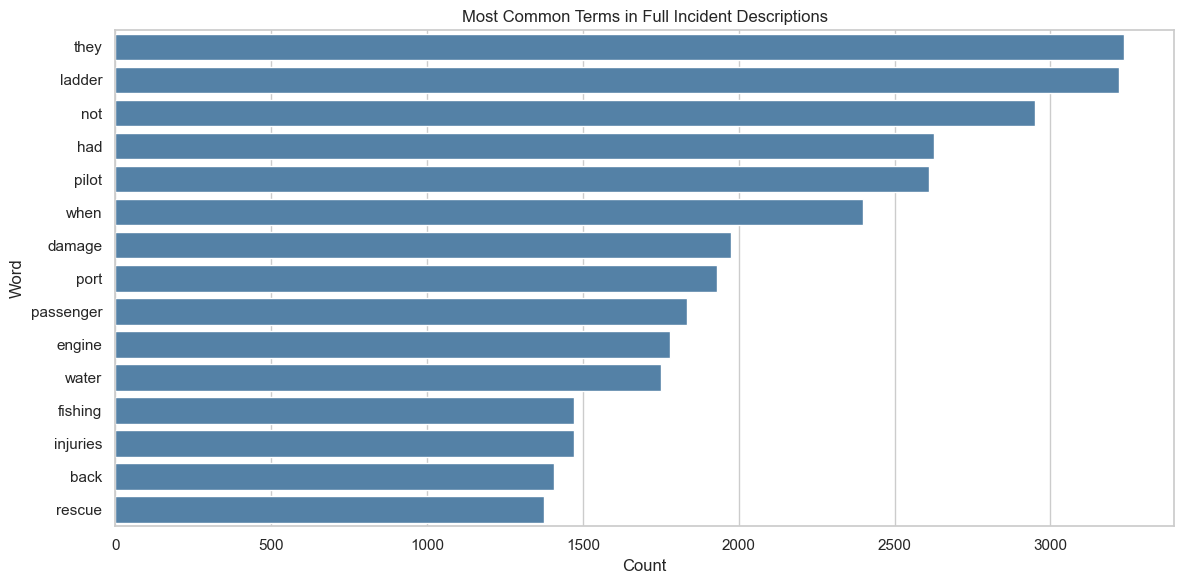

In [14]:
# -----------------------------
# 12. PLOT TOP TERMS IN FULL DESCRIPTIONS
# -----------------------------
plt.figure(figsize=(12, 6))
sns.barplot(data=full_counts.head(15), x="count", y="word", color="steelblue")
plt.title("Most Common Terms in Full Incident Descriptions")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

In [15]:
# -----------------------------
# 13. NARRATIVE LENGTH BY SEVERITY
# -----------------------------
severity_length = (
    df.groupby("severityplot")
      .agg(
          incidents=("severityplot", "size"),
          avg_desc_chars=("full_desc_chars", "mean"),
          median_desc_chars=("full_desc_chars", "median")
      )
      .reset_index()
      .sort_values("avg_desc_chars", ascending=False)
)

print("\n===== DESCRIPTION LENGTH BY SEVERITY =====")
print(severity_length.round(2))


===== DESCRIPTION LENGTH BY SEVERITY =====
      severityplot  incidents  avg_desc_chars  median_desc_chars
2          Serious        426          328.55              283.0
0     Less Serious       3116          308.98              272.0
1  Marine Incident       4759          286.78              240.0
3     Very Serious        298          256.46              228.0


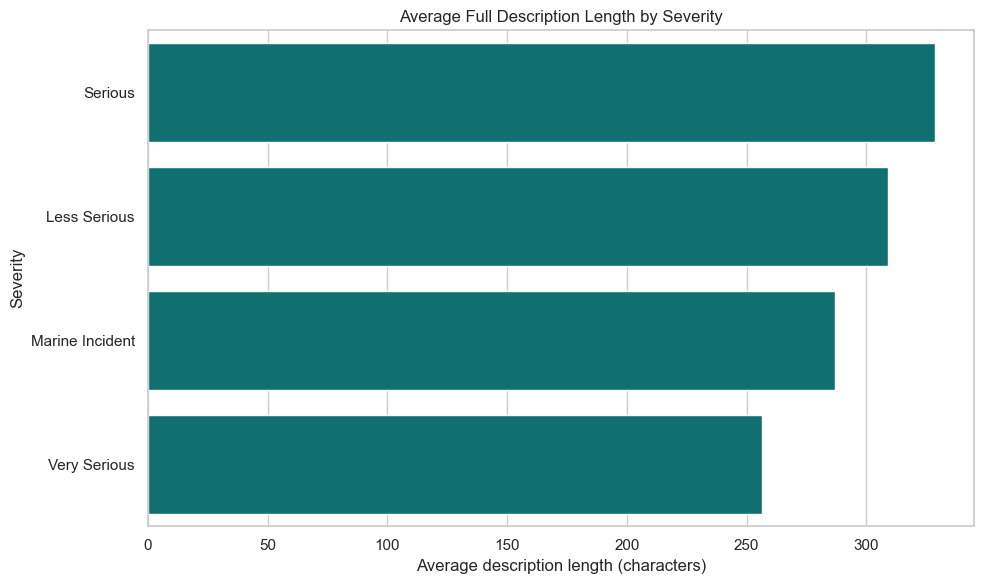

In [16]:
# -----------------------------
# 14. PLOT NARRATIVE LENGTH BY SEVERITY
# -----------------------------
plt.figure(figsize=(10, 6))
sns.barplot(data=severity_length, x="avg_desc_chars", y="severityplot", color="teal")
plt.title("Average Full Description Length by Severity")
plt.xlabel("Average description length (characters)")
plt.ylabel("Severity")
plt.tight_layout()
plt.show()

In [17]:
# -----------------------------
# 15. NARRATIVE LENGTH BY SAR
# -----------------------------
sar_length = (
    df.groupby("sarplot")
      .agg(
          incidents=("sarplot", "size"),
          avg_desc_chars=("full_desc_chars", "mean"),
          median_desc_chars=("full_desc_chars", "median")
      )
      .reset_index()
)

sar_order = ["No", "Yes", "Unknown"]
sar_length["sarplot"] = pd.Categorical(sar_length["sarplot"], categories=sar_order, ordered=True)
sar_length = sar_length.sort_values("sarplot")

print("\n===== DESCRIPTION LENGTH BY SAR =====")
print(sar_length.round(2))


===== DESCRIPTION LENGTH BY SAR =====
   sarplot  incidents  avg_desc_chars  median_desc_chars
0       No       6833          305.55              261.0
2      Yes       1747          258.56              225.0
1  Unknown         19          232.84              174.0


In [18]:
# -----------------------------
# 16. YEARLY TREND IN DESCRIPTION LENGTH
# -----------------------------
yearly_narrative = (
    df.dropna(subset=["eventyear"])
      .groupby("eventyear")
      .agg(
          incidents=("eventyear", "size"),
          avg_desc_chars=("full_desc_chars", "mean")
      )
      .reset_index()
      .sort_values("eventyear")
)

print("\n===== YEARLY TREND IN NARRATIVE LENGTH =====")
print(yearly_narrative.round(2))


===== YEARLY TREND IN NARRATIVE LENGTH =====
   eventyear  incidents  avg_desc_chars
0       2018          3           71.67
1       2019         18          130.39
2       2020       1215          174.79
3       2021       1499          269.01
4       2022       1256          327.34
5       2023       1592          344.98
6       2024       1514          319.28
7       2025       1502          320.93


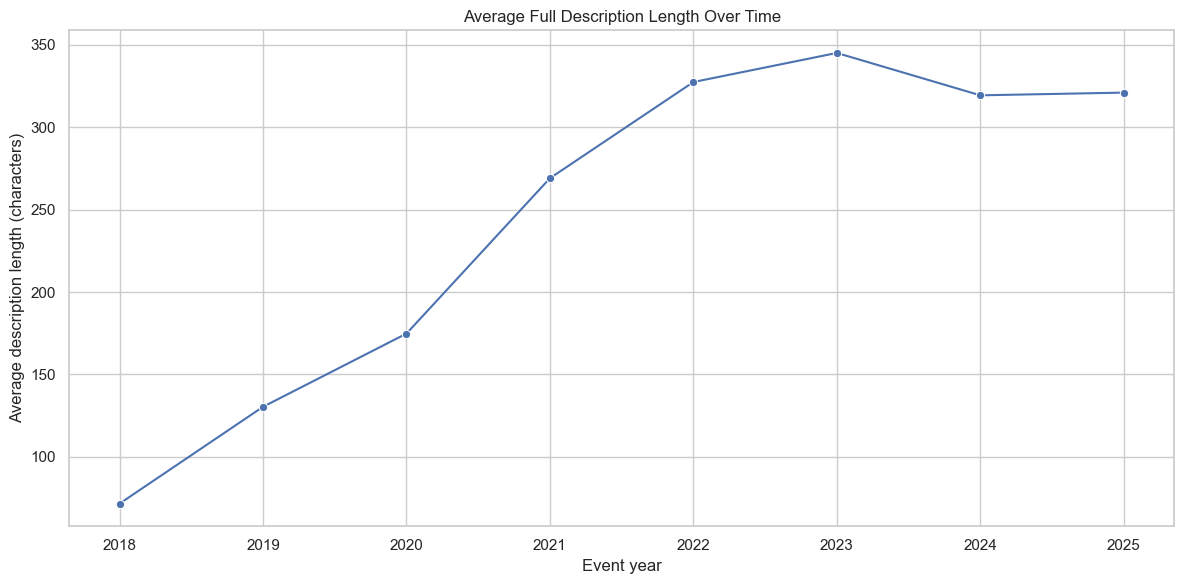

In [19]:
# -----------------------------
# 17. PLOT YEARLY TREND IN DESCRIPTION LENGTH
# -----------------------------
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_narrative, x="eventyear", y="avg_desc_chars", marker="o")
plt.title("Average Full Description Length Over Time")
plt.xlabel("Event year")
plt.ylabel("Average description length (characters)")
plt.tight_layout()
plt.show()

In [22]:
# -----------------------------
# 18. FINAL TAKEAWAYS
# -----------------------------
print("\n===== PART 6 TAKEAWAYS =====")
print("- This notebook focuses on narrative fields rather than coded category fields.")
print("- It checks description completeness, compares narrative richness, and surfaces example incidents.")
print("- It also shows recurring language patterns and whether narrative length varies by severity, SAR, or year.")


===== PART 6 TAKEAWAYS =====
- This notebook focuses on narrative fields rather than coded category fields.
- It checks description completeness, compares narrative richness, and surfaces example incidents.
- It also shows recurring language patterns and whether narrative length varies by severity, SAR, or year.
